In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay)

sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print(f"Shape: {df.shape}")

Shape: (768, 9)


In [5]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


/tmp/ipykernel_2649/2022769421.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outcome', palette='Set2')


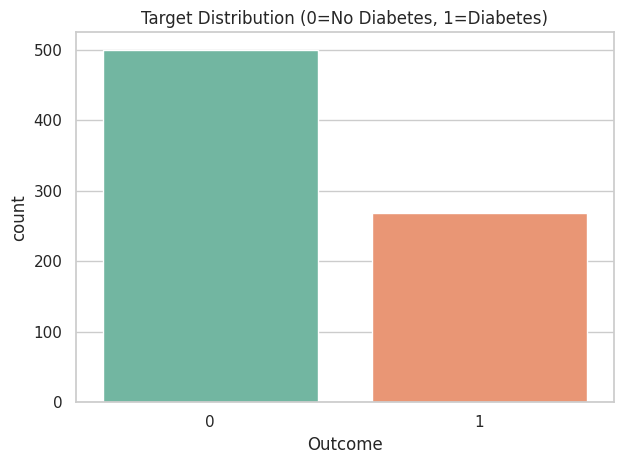

In [10]:
sns.countplot(data=df, x='Outcome', palette='Set2')
plt.title('Target Distribution (0=No Diabetes, 1=Diabetes)')
plt.xlabel('Outcome')
plt.tight_layout()
plt.show()

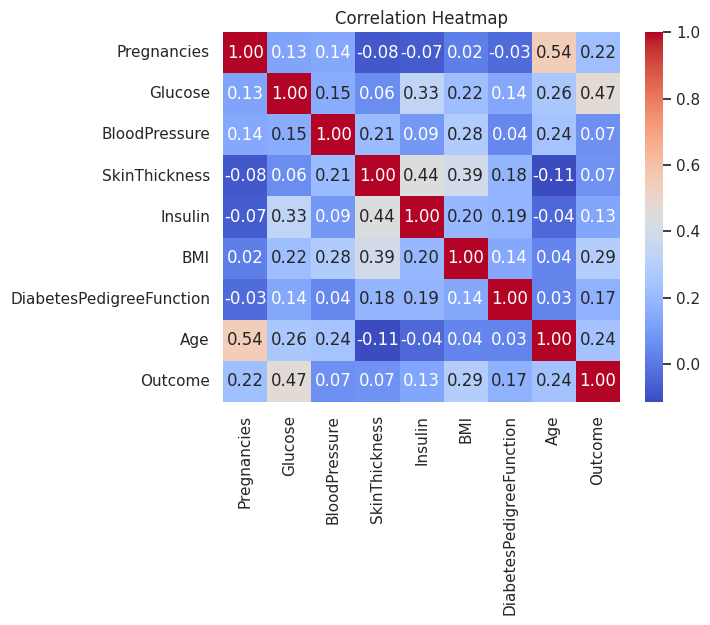

In [13]:
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

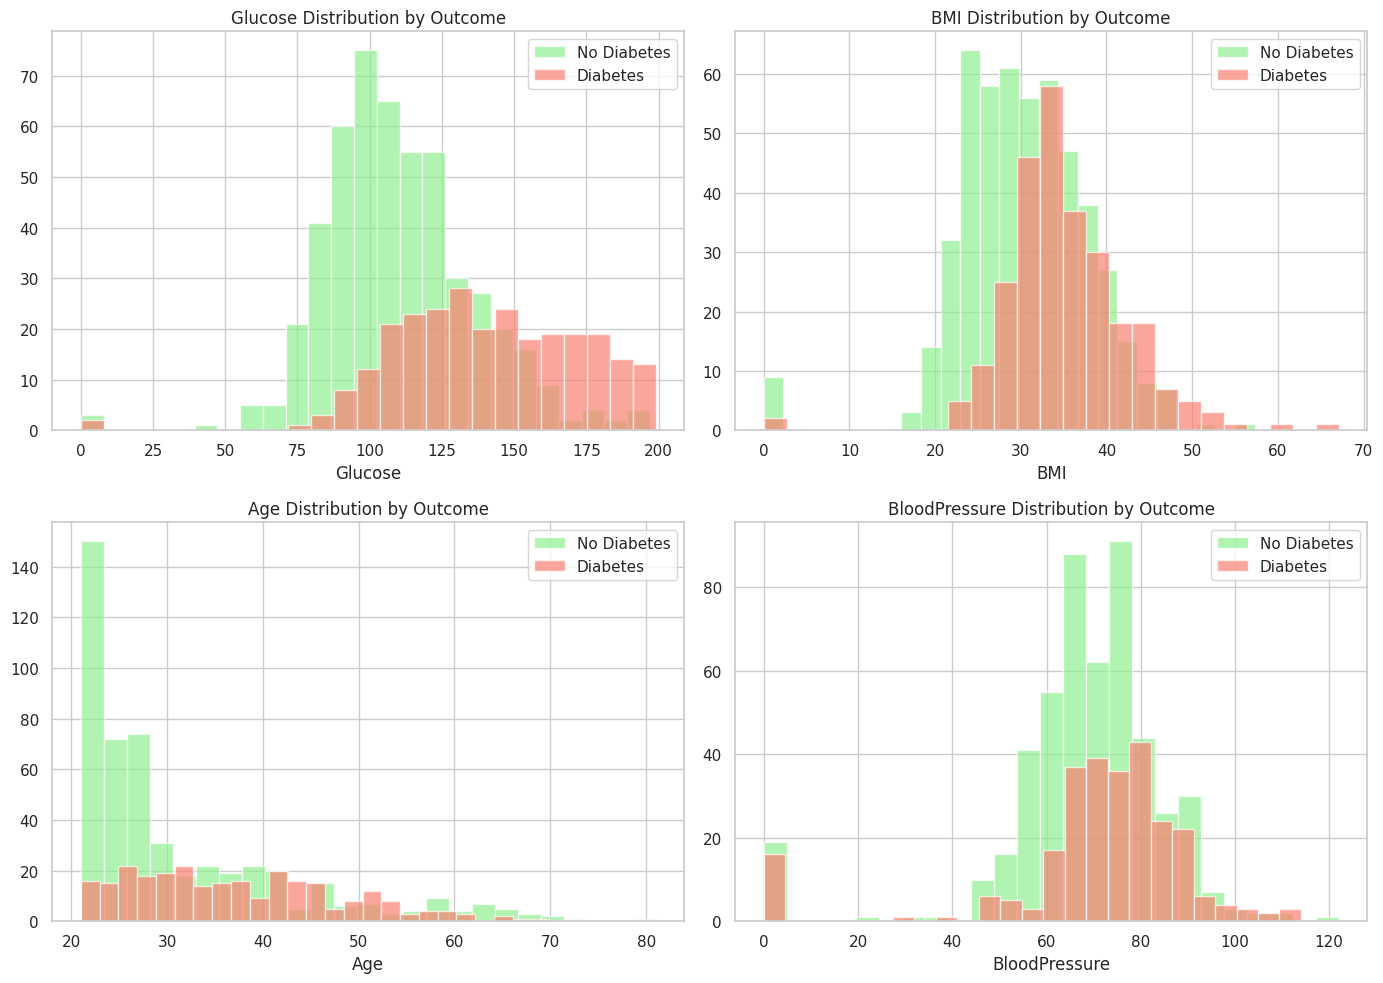

In [14]:
features = ['Glucose', 'BMI', 'Age', 'BloodPressure']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(features):
    df[df['Outcome']==0][feature].hist(bins=25, alpha=0.7, color='lightgreen',
                                        label='No Diabetes', ax=axes[idx])
    df[df['Outcome']==1][feature].hist(bins=25, alpha=0.7, color='salmon',
                                        label='Diabetes', ax=axes[idx])
    axes[idx].set_title(f'{feature} Distribution by Outcome')
    axes[idx].set_xlabel(feature)
    axes[idx].legend()

plt.tight_layout()
plt.show()

# **Define Variables**

In [15]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

In [16]:
print("Features:", X.columns.tolist())
print("Target:  ", y.name)

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target:   Outcome


# **Train-Test Split**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (614, 8)
Test size:  (154, 8)


# **Feature Engineering**

In [21]:
# Columns where 0 means missing (medically impossible to have 0)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [22]:
# Replacing 0 with NaN
X_train[zero_cols] = X_train[zero_cols].replace(0, np.nan)
X_test[zero_cols]  = X_test[zero_cols].replace(0, np.nan)

In [23]:
for col in zero_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col]  = X_test[col].fillna(median_val)

In [25]:
X_train.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0


# **Feature Scaling**

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [28]:
print(f"Train mean: {X_train_scaled.mean():.4f}")
print(f"Train std: {X_train_scaled.std():.4f}")

Train mean: 0.0000
Train std: 1.0000


# **Train**

In [29]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

# **Predict**

In [30]:
y_pred = knn.predict(X_test_scaled)

In [31]:
y_prob = knn.predict_proba(X_test_scaled)[:, 1]

# **Evaluate Model**

In [32]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Accuracy: 0.7532
ROC-AUC: 0.7899


In [33]:
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



# **Confusion Matrix**

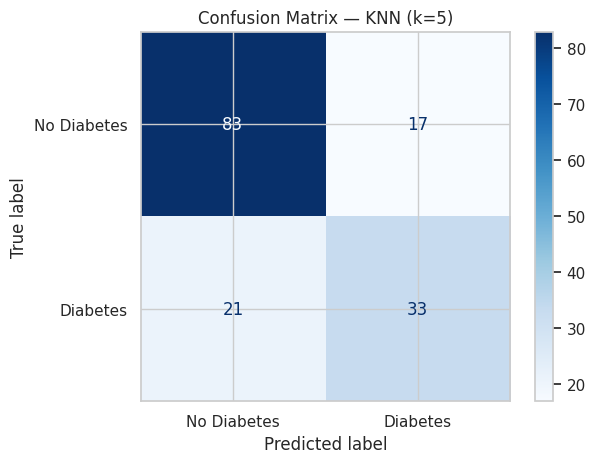

In [35]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — KNN (k=5)')
plt.show()

# **ROC Curve**

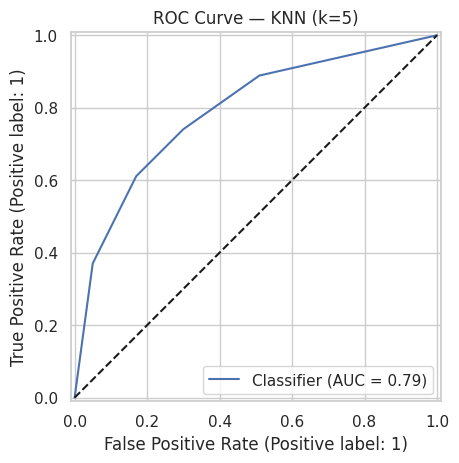

In [37]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('ROC Curve — KNN (k=5)')
plt.plot([0,1],[0,1],'k--')
plt.show()

# **Trying Different k Values**

In [38]:
k_values = [3, 5, 7, 9, 11, 15, 21]
accuracies = []
roc_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    accuracies.append(accuracy_score(y_test, preds))
    roc_scores.append(roc_auc_score(y_test, probs))
    print(f"k={k:<3} → Accuracy: {accuracy_score(y_test, preds):.4f} | ROC-AUC: {roc_auc_score(y_test, probs):.4f}")

k=3   → Accuracy: 0.7208 | ROC-AUC: 0.7675
k=5   → Accuracy: 0.7532 | ROC-AUC: 0.7899
k=7   → Accuracy: 0.7273 | ROC-AUC: 0.7900
k=9   → Accuracy: 0.7403 | ROC-AUC: 0.7951
k=11  → Accuracy: 0.7338 | ROC-AUC: 0.7880
k=15  → Accuracy: 0.7403 | ROC-AUC: 0.8068
k=21  → Accuracy: 0.7597 | ROC-AUC: 0.8120


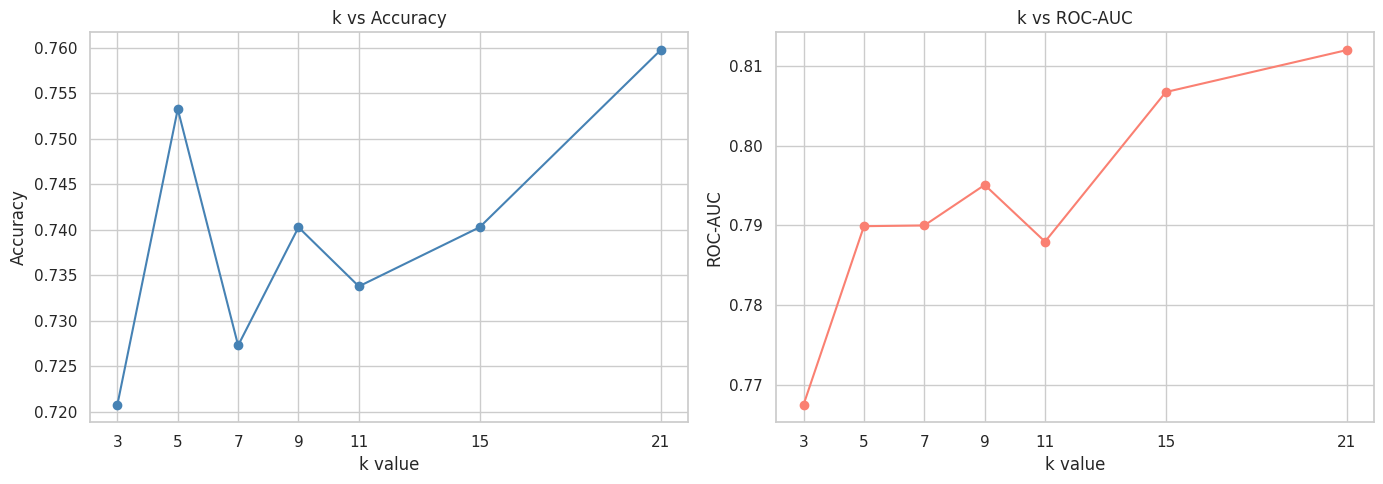


Best k = 21 with accuracy = 0.7597


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, accuracies, marker='o', color='steelblue')
axes[0].set_title('k vs Accuracy')
axes[0].set_xlabel('k value')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(k_values)

axes[1].plot(k_values, roc_scores, marker='o', color='salmon')
axes[1].set_title('k vs ROC-AUC')
axes[1].set_xlabel('k value')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_xticks(k_values)

plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"\nBest k = {best_k} with accuracy = {max(accuracies):.4f}")